# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Rifqi Zaghlul Musyaffa
- **Email:** rifqizaghlul1@gmail.com
- **ID Dicoding:** jaglul

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow version:', tf.__version__)
print('GPU tersedia:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [2]:
!unzip "/content/Rice Leaf Disease.zip" -d "/content/dataset_rice/"

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_144.JPG  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_145.JPG  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_146.JPG  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_147.jpg  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_148.jpg  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_149.jpg  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_150.jpg  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_151.jpg  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIALBLIGHT1_152.jpg  
  inflating: /content/dataset_rice/Rice Leaf Disease/Bacterialblight/BACTERIA

In [3]:
# Input Dataset

DATASET_DIR  = Path('/content/dataset_rice/Rice Leaf Disease')  # <-- GANTI SESUAI PATH KAMU

status = 'Ada' if DATASET_DIR.exists() else 'Tidak Ada'
print(f'Dataset dir : {DATASET_DIR}  {status}')

if DATASET_DIR.exists():
    class_dirs = sorted([d for d in DATASET_DIR.iterdir() if d.is_dir()])
    print(f'Kelas ditemukan ({len(class_dirs)}):', [d.name for d in class_dirs])

Dataset dir : /content/dataset_rice/Rice Leaf Disease  Ada
Kelas ditemukan (4): ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [4]:
# Cek jumlah gambar dan resolusi per kelas (sesuai tips Dicoding)
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0
    directory = str(directory)

    for subdir in sorted(os.listdir(directory)):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path):
            continue
        image_files = [f for f in os.listdir(subdir_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        num_images = len(image_files)
        print(f'{subdir}: {num_images}')
        total_images += num_images

        for img_file in image_files[:5]:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f'  - {size[0]}x{size[1]} px')
        print('---------------')

    print(f'\nTotal: {total_images}')

print('=== DATASET ASLI ===')
print_images_resolution(DATASET_DIR)

=== DATASET ASLI ===
Bacterialblight: 1584
  - 300x300 px
---------------
Blast: 1440
  - 300x300 px
---------------
Brownspot: 1600
  - 300x300 px
---------------
Tungro: 1308
  - 511x341 px
  - 517x344 px
  - 301x227 px
  - 340x510 px
  - 227x301 px
  - 300x300 px
---------------

Total: 5932


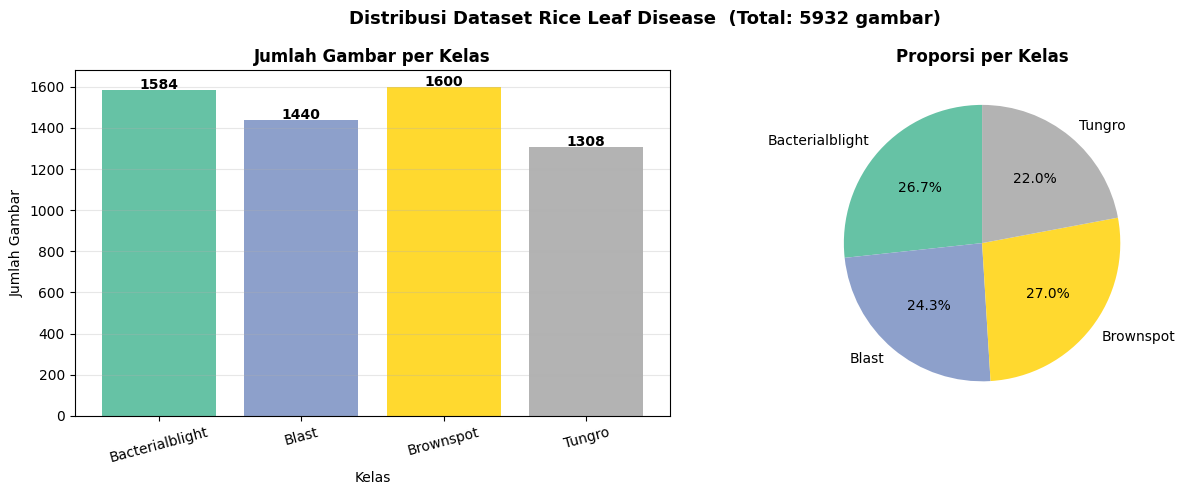

In [5]:
# Visualisasi distribusi kelas sebelum split
class_counts = {}
for cls_dir in class_dirs:
    imgs = [f for f in cls_dir.iterdir()
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    class_counts[cls_dir.name] = len(imgs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(class_counts)))
axes[0].bar(class_counts.keys(), class_counts.values(), color=colors)
axes[0].set_title('Jumlah Gambar per Kelas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Proporsi per Kelas', fontsize=12, fontweight='bold')

plt.suptitle(f'Distribusi Dataset Rice Leaf Disease  (Total: {sum(class_counts.values())} gambar)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

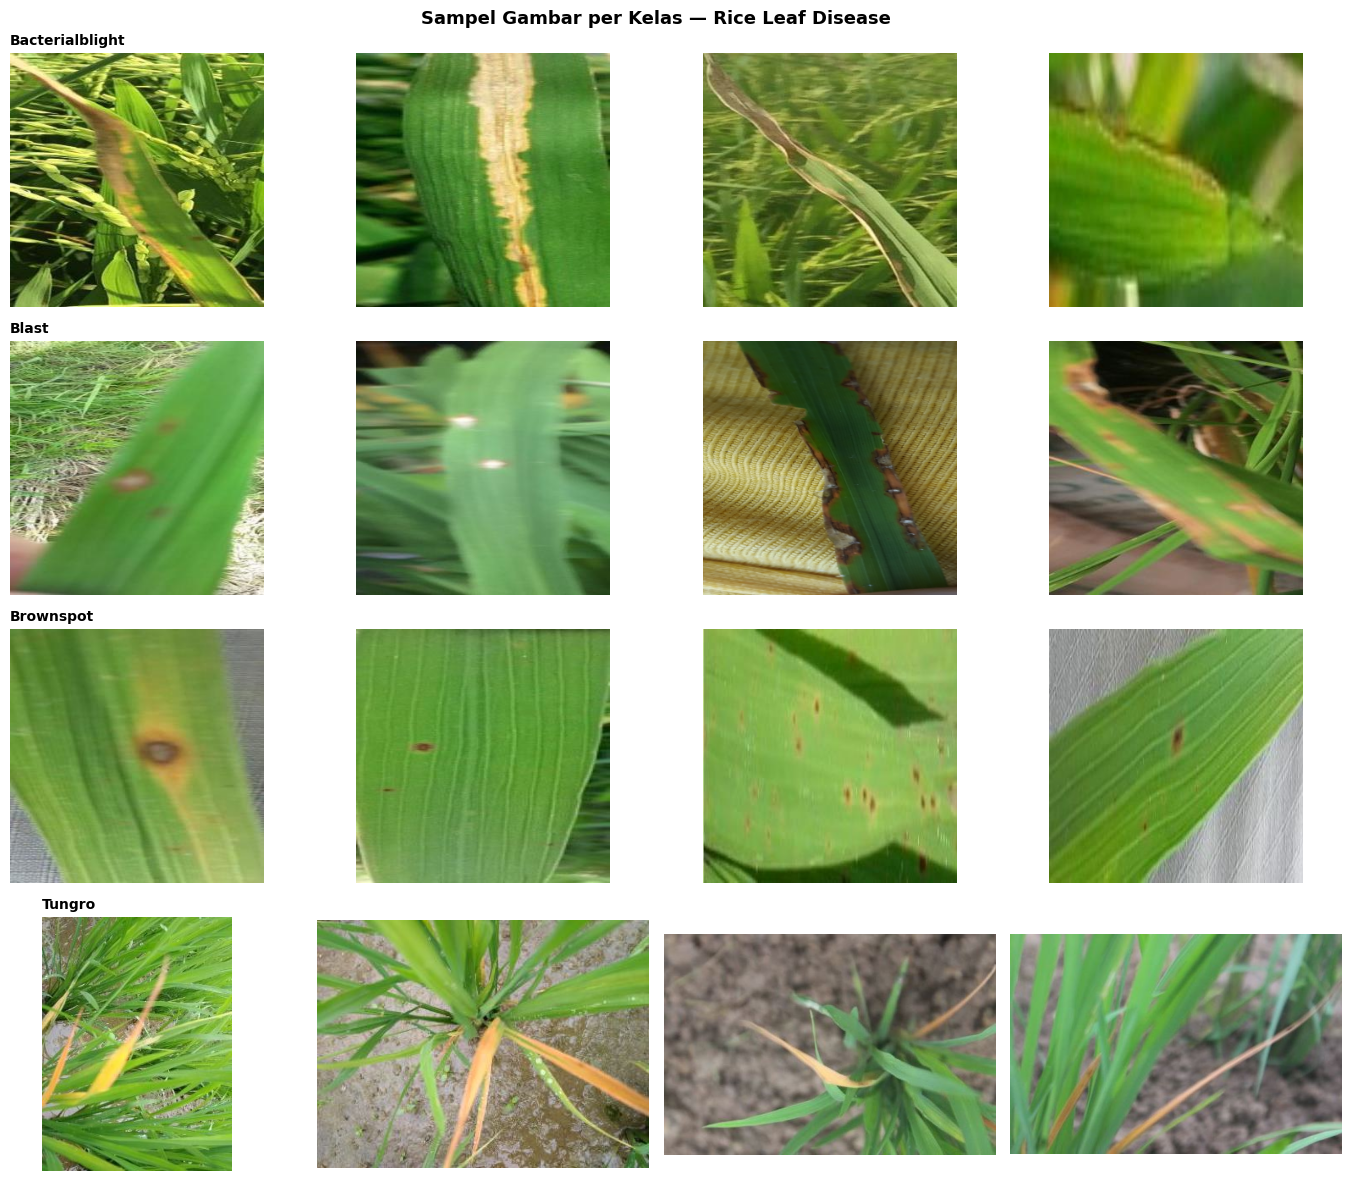

In [6]:
# Tampilkan sampel gambar tiap kelas
fig, axes = plt.subplots(len(class_dirs), 4, figsize=(14, len(class_dirs) * 3))

for i, cls_dir in enumerate(class_dirs):
    imgs = [f for f in cls_dir.iterdir()
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    samples = random.sample(imgs, min(4, len(imgs)))
    for j, img_path in enumerate(samples):
        img = mpimg.imread(str(img_path))
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
    axes[i][0].set_title(cls_dir.name, fontsize=10, fontweight='bold', loc='left')

plt.suptitle('Sampel Gambar per Kelas — Rice Leaf Disease',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Preprocessing

Split dataset manual dengan rasio:
- **70%** → Train
- **15%** → Validation
- **15%** → Test

Proses split dilakukan secara **stratified per kelas** agar proporsi tiap kelas terjaga di semua split.

#### Split Dataset

In [7]:
import shutil

# Split manual: 70% train, 15% val, 15% test
SPLIT_DIR = Path('/content/rice_split')
TRAIN_DIR = SPLIT_DIR / 'train'
VAL_DIR   = SPLIT_DIR / 'validation'
TEST_DIR  = SPLIT_DIR / 'test'

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15 (sisa otomatis)

random.seed(42)
np.random.seed(42)

# Hapus folder split lama jika ada
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
    print('Folder split lama dihapus.')

split_summary = {}

for cls_dir in class_dirs:
    cls_name = cls_dir.name
    all_imgs = [f for f in cls_dir.iterdir()
                if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    random.shuffle(all_imgs)

    n       = len(all_imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    train_imgs = all_imgs[:n_train]
    val_imgs   = all_imgs[n_train:n_train + n_val]
    test_imgs  = all_imgs[n_train + n_val:]

    split_summary[cls_name] = {
        'total': n,
        'train': len(train_imgs),
        'validation': len(val_imgs),
        'test': len(test_imgs)
    }

    # Copy file ke direktori split
    for split_name, imgs, dest_root in [
        ('train',      train_imgs, TRAIN_DIR),
        ('validation', val_imgs,   VAL_DIR),
        ('test',       test_imgs,  TEST_DIR)
    ]:
        dest = dest_root / cls_name
        dest.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            shutil.copy(img, dest / img.name)

# Tampilkan ringkasan
print('Ringkasan Split Dataset:')
print(f"{'Kelas':<18} {'Total':>7} {'Train':>7} {'Val':>7} {'Test':>7}")
print('-' * 50)
totals = {'total': 0, 'train': 0, 'validation': 0, 'test': 0}
for cls, counts in split_summary.items():
    print(f"{cls:<18} {counts['total']:>7} {counts['train']:>7} "
          f"{counts['validation']:>7} {counts['test']:>7}")
    for k in totals:
        totals[k] += counts[k]
print('-' * 50)
print(f"{'TOTAL':<18} {totals['total']:>7} {totals['train']:>7} "
      f"{totals['validation']:>7} {totals['test']:>7}")
print(f"\nRasio   :  100%   "
      f"{totals['train']/totals['total']*100:.1f}%  "
      f"{totals['validation']/totals['total']*100:.1f}%  "
      f"{totals['test']/totals['total']*100:.1f}%")
print(f'\nFolder split tersimpan di: {SPLIT_DIR}')

Ringkasan Split Dataset:
Kelas                Total   Train     Val    Test
--------------------------------------------------
Bacterialblight       1584    1108     237     239
Blast                 1440    1007     216     217
Brownspot             1600    1120     240     240
Tungro                1308     915     196     197
--------------------------------------------------
TOTAL                 5932    4150     889     893

Rasio   :  100%   70.0%  15.0%  15.1%

Folder split tersimpan di: /content/rice_split


In [8]:
# Konfigurasi
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 30
NUM_CLASSES = len(class_dirs)

print('Konfigurasi Training:')
print(f'  Image size  : {IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Max epochs  : {EPOCHS}')
print(f'  Num classes : {NUM_CLASSES}  {[d.name for d in class_dirs]}')

Konfigurasi Training:
  Image size  : (224, 224)
  Batch size  : 32
  Max epochs  : 30
  Num classes : 4  ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [9]:
# Augmentasi pada training — val & test hanya rescale
# Augmentasi diperlukan karena dataset relatif kecil (~5932 gambar, 4 kelas)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    shear_range=0.10,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
print('\nLabel index:', train_generator.class_indices)

Found 4150 images belonging to 4 classes.
Found 889 images belonging to 4 classes.
Found 893 images belonging to 4 classes.

Label index: {'Bacterialblight': 0, 'Blast': 1, 'Brownspot': 2, 'Tungro': 3}


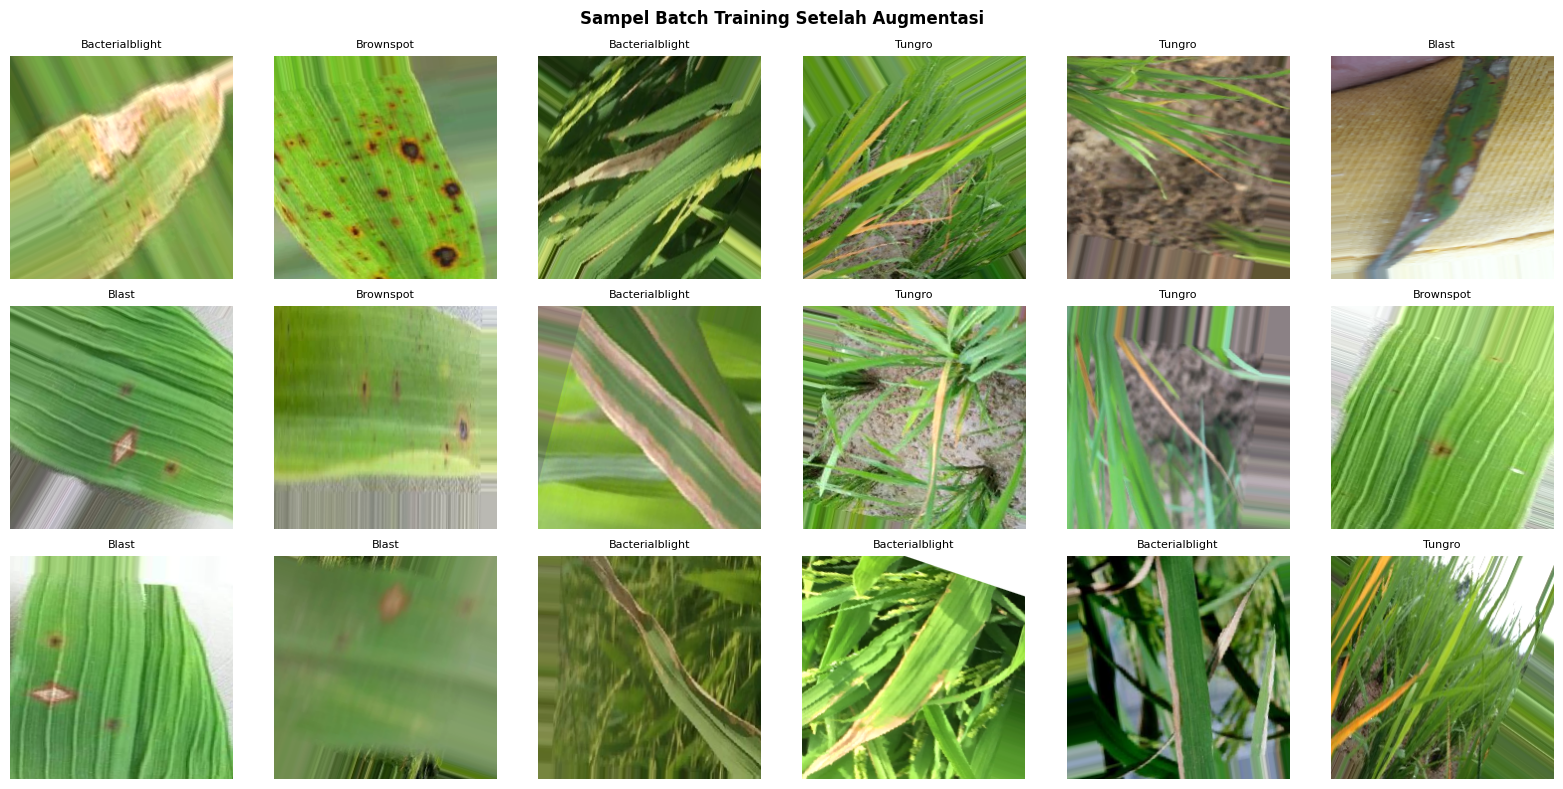

In [10]:
# Visualisasi sampel batch setelah augmentasi
sample_batch, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < len(sample_batch):
        ax.imshow(sample_batch[i])
        cls_idx = np.argmax(sample_labels[i])
        ax.set_title(class_labels[cls_idx], fontsize=8)
    ax.axis('off')

plt.suptitle('Sampel Batch Training Setelah Augmentasi',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Modelling

In [11]:
# Arsitektur CNN Sequential
# 4 blok Conv2D + MaxPooling2D → Flatten → Dense → Softmax (4 kelas)
model = Sequential([

    # Block 1  (224 → 112)
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(224, 224, 3), name='conv1_1'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
    BatchNormalization(),
    MaxPooling2D((2, 2), name='pool1'),
    Dropout(0.25),

    # Block 2  (112 → 56)
    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
    BatchNormalization(),
    MaxPooling2D((2, 2), name='pool2'),
    Dropout(0.25),

    # Block 3  (56 → 28)
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
    BatchNormalization(),
    MaxPooling2D((2, 2), name='pool3'),
    Dropout(0.30),

    # Block 4  (28 → 14)
    Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_1'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_2'),
    BatchNormalization(),
    MaxPooling2D((2, 2), name='pool4'),
    Dropout(0.30),

    # Classifier Head
    Flatten(),
    Dense(512, activation='relu', name='fc1'),
    BatchNormalization(),
    Dropout(0.50),
    Dense(256, activation='relu', name='fc2'),
    BatchNormalization(),
    Dropout(0.40),
    Dense(NUM_CLASSES, activation='softmax', name='output')

], name='RiceLeafDiseaseCNN')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "RiceLeafDiseaseCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_2 (Conv2D)                │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 27,002,148 (103.01 MB)

 Trainable params: 26,998,692 (102.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [12]:
# Kompilasi model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    # [1] Hentikan training jika val_accuracy tidak naik dalam 8 epoch
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # [2] Simpan bobot terbaik secara otomatis
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # [3] Turunkan learning rate jika val_loss stagnan 4 epoch
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

print('3 Callbacks aktif:')
print('  [1] EarlyStopping     — monitor=val_accuracy, patience=8')
print('  [2] ModelCheckpoint   — simpan bobot terbaik')
print('  [3] ReduceLROnPlateau — monitor=val_loss, patience=4, factor=0.5')

3 Callbacks aktif:
  [1] EarlyStopping     — monitor=val_accuracy, patience=8
  [2] ModelCheckpoint   — simpan bobot terbaik
  [3] ReduceLROnPlateau — monitor=val_loss, patience=4, factor=0.5


In [13]:
# Training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.5909 - loss: 1.2622
Epoch 1: val_accuracy improved from None to 0.26997, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 137s 791ms/step - accuracy: 0.6463 - loss: 1.0655 - val_accuracy: 0.2700 - val_loss: 7.1837 - learning_rate: 0.0010
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.7373 - loss: 0.7596
Epoch 2: val_accuracy improved from 0.26997 to 0.27222, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 74s 566ms/step - accuracy: 0.7583 - loss: 0.6903 - val_accuracy: 0.2722 - val_loss: 4.5918 - learning_rate: 0.0010
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.8183 - loss: 0.4974
Epoch 3: val_accuracy improved from 0.27222 to 0.46794, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━

## Evaluasi dan Visualisasi

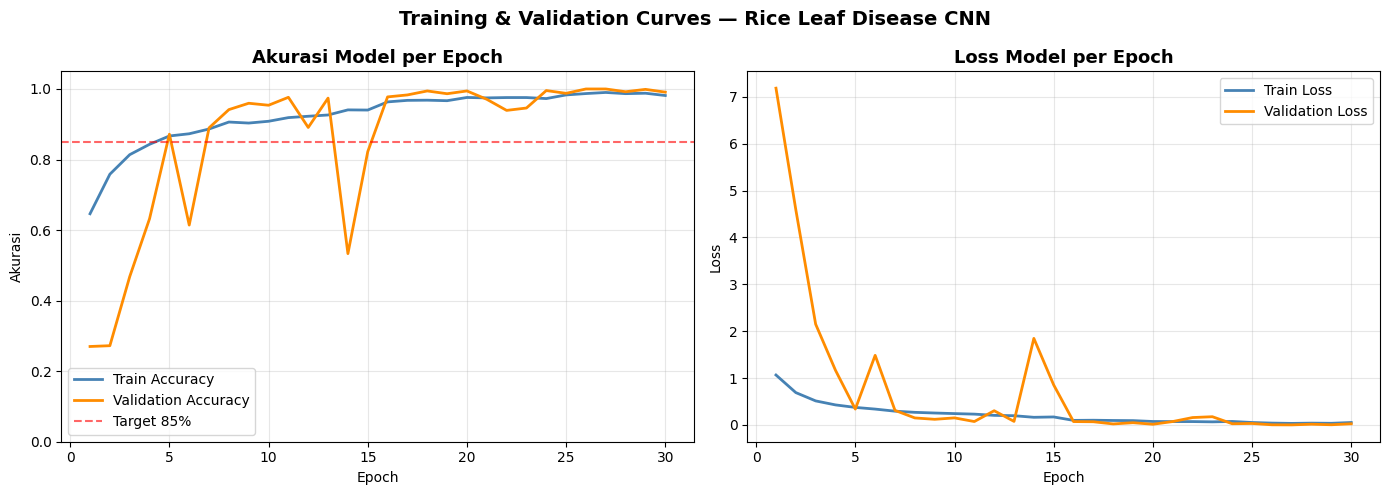

Disimpan: training_curves.png


In [14]:
# Plot Akurasi & Loss
epochs_ran = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history.history['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'],
             label='Validation Accuracy', color='darkorange', linewidth=2)
axes[0].axhline(y=0.85, color='red', linestyle='--', alpha=0.6, label='Target 85%')
axes[0].set_title('Akurasi Model per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1.05])

axes[1].plot(epochs_ran, history.history['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'],
             label='Validation Loss', color='darkorange', linewidth=2)
axes[1].set_title('Loss Model per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training & Validation Curves — Rice Leaf Disease CNN',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disimpan: training_curves.png')

In [15]:
# Evaluasi numerik pada semua split
print('=' * 55)
print('EVALUASI MODEL')
print('=' * 55)

train_loss, train_acc = model.evaluate(train_generator, verbose=0)
val_loss,   val_acc   = model.evaluate(val_generator,   verbose=0)
test_loss,  test_acc  = model.evaluate(test_generator,  verbose=0)

print(f'  Train Accuracy      : {train_acc*100:.2f}%')
print(f'  Validation Accuracy : {val_acc*100:.2f}%')
print(f'  Test Accuracy       : {test_acc*100:.2f}%')
print(f'  Train Loss          : {train_loss:.4f}')
print(f'  Validation Loss     : {val_loss:.4f}')
print(f'  Test Loss           : {test_loss:.4f}')
print()
if train_acc >= 0.85 and test_acc >= 0.85:
    print('Kriteria akurasi minimal 85% TERPENUHI!')
else:
    print('Akurasi belum 85%. Coba tambah epoch atau tuning lebih lanjut.')

EVALUASI MODEL
  Train Accuracy      : 99.61%
  Validation Accuracy : 100.00%
  Test Accuracy       : 100.00%
  Train Loss          : 0.0117
  Validation Loss     : 0.0035
  Test Loss           : 0.0017

Kriteria akurasi minimal 85% TERPENUHI!


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step


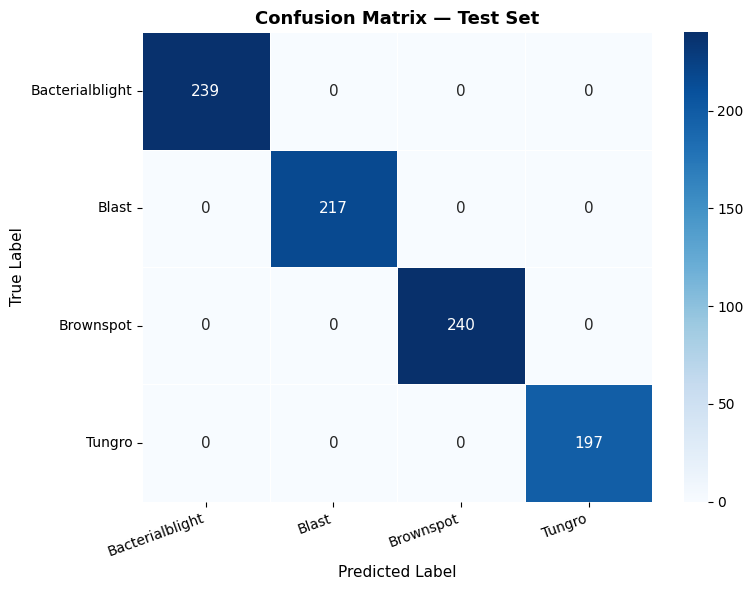


Classification Report:
                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       239
          Blast       1.00      1.00      1.00       217
      Brownspot       1.00      1.00      1.00       240
         Tungro       1.00      1.00      1.00       197

       accuracy                           1.00       893
      macro avg       1.00      1.00      1.00       893
   weighted avg       1.00      1.00      1.00       893



In [16]:
# Confusion Matrix & Classification Report
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_labels))

## Konversi Model

In [17]:
# 1. SavedModel
SAVED_MODEL_DIR = 'saved_model'
model.export(SAVED_MODEL_DIR)
print(f'SavedModel disimpan di: {SAVED_MODEL_DIR}/')

_ = tf.saved_model.load(SAVED_MODEL_DIR)
print('Verifikasi load: berhasil')

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137901717569808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137903652191696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717570192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717571728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137903652190736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717571920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717572112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717571536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717572496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717573648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137901717573456: Te

In [18]:
# 2. TF-Lite
TFLITE_DIR = 'tflite'
os.makedirs(TFLITE_DIR, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = os.path.join(TFLITE_DIR, 'model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

label_path = os.path.join(TFLITE_DIR, 'label.txt')
with open(label_path, 'w') as f:
    for lbl in class_labels:
        f.write(lbl + '\n')

size_mb = os.path.getsize(tflite_path) / (1024 ** 2)
print(f'  TF-Lite disimpan di   : {tflite_path}  ({size_mb:.2f} MB)')
print(f'   Label disimpan di    : {label_path}')
print(f'   Kelas                : {class_labels}')

  TF-Lite disimpan di   : tflite/model.tflite  (25.79 MB)
   Label disimpan di    : tflite/label.txt
   Kelas                : ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [19]:
# 3. TensorFlow.js
!pip install tensorflowjs -q

TFJS_DIR = 'tfjs_model'
os.makedirs(TFJS_DIR, exist_ok=True)

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    saved_model/ tfjs_model/

print('\n TFJS model disimpan di: tfjs_model/')
print('   File:')
for f in sorted(os.listdir(TFJS_DIR)):
    kb = os.path.getsize(os.path.join(TFJS_DIR, f)) / 1024
    print(f'   - {f}  ({kb:.0f} KB)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
2026-04-06 09:50:13.274566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775469013.308798   15829 cuda_dnn.cc:8579] Unable to register cuDNN fac

In [20]:
# Ringkasan struktur direktori submission
print('=' * 55)
print('STRUKTUR DIREKTORI SUBMISSION')
print('=' * 55)
for folder in ['saved_model', 'tflite', 'tfjs_model']:
    total_kb = 0
    print(f'\n {folder}/')
    for root, dirs, files in os.walk(folder):
        for fname in sorted(files):
            fpath = os.path.join(root, fname)
            kb = os.path.getsize(fpath) / 1024
            total_kb += kb
            rel = os.path.relpath(fpath, folder)
            print(f'   ├── {rel}  ({kb:.0f} KB)')
    print(f'   [Total: {total_kb/1024:.2f} MB]')

STRUKTUR DIREKTORI SUBMISSION

 saved_model/
   ├── fingerprint.pb  (0 KB)
   ├── saved_model.pb  (414 KB)
   ├── variables/variables.data-00000-of-00001  (210970 KB)
   ├── variables/variables.index  (7 KB)
   [Total: 206.44 MB]

 tflite/
   ├── label.txt  (0 KB)
   ├── model.tflite  (26410 KB)
   [Total: 25.79 MB]

 tfjs_model/
   ├── group1-shard10of26.bin  (4096 KB)
   ├── group1-shard11of26.bin  (4096 KB)
   ├── group1-shard12of26.bin  (4096 KB)
   ├── group1-shard13of26.bin  (4096 KB)
   ├── group1-shard14of26.bin  (4096 KB)
   ├── group1-shard15of26.bin  (4096 KB)
   ├── group1-shard16of26.bin  (4096 KB)
   ├── group1-shard17of26.bin  (4096 KB)
   ├── group1-shard18of26.bin  (4096 KB)
   ├── group1-shard19of26.bin  (4096 KB)
   ├── group1-shard1of26.bin  (4096 KB)
   ├── group1-shard20of26.bin  (4096 KB)
   ├── group1-shard21of26.bin  (4096 KB)
   ├── group1-shard22of26.bin  (4096 KB)
   ├── group1-shard23of26.bin  (4096 KB)
   ├── group1-shard24of26.bin  (4096 KB)
   ├── group1

## Inference (Optional)

In [21]:
# Inference menggunakan TF-Lite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('TFLite Interpreter siap.')
print(f'  Input  shape : {input_details[0]["shape"]}')
print(f'  Output shape : {output_details[0]["shape"]}')

def predict_tflite(img_path):
    """Prediksi satu gambar menggunakan TFLite interpreter."""
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)          # (1, 224, 224, 3)
    interpreter.set_tensor(input_details[0]['index'], arr)
    interpreter.invoke()
    probs      = interpreter.get_tensor(output_details[0]['index'])[0]
    pred_idx   = int(np.argmax(probs))
    pred_lbl   = class_labels[pred_idx]
    confidence = float(probs[pred_idx]) * 100
    return pred_lbl, confidence, probs

TFLite Interpreter siap.
  Input  shape : [  1 224 224   3]
  Output shape : [1 4]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


HASIL INFERENCE — TF-LITE MODEL

[1] BACTERIALBLIGHT1_154.jpg
  True Label  : Bacterialblight
  Prediction  : Bacterialblight (100.0%) Berhasil
  Probabilities:
    Bacterialblight 100.0%  ████████████████████████
    Blast      0.0%  
    Tungro     0.0%  
    Brownspot   0.0%  

[2] BLAST6_150.JPG
  True Label  : Blast
  Prediction  : Blast (99.4%) Berhasil
  Probabilities:
    Blast     99.4%  ████████████████████████
    Bacterialblight   0.3%  
    Brownspot   0.1%  
    Tungro     0.1%  

[3] BROWNSPOT3_100.jpg
  True Label  : Brownspot
  Prediction  : Brownspot (100.0%) Berhasil
  Probabilities:
    Brownspot 100.0%  ████████████████████████
    Blast      0.0%  
    Bacterialblight   0.0%  
    Tungro     0.0%  

[4] TUNGRO3_095.JPG
  True Label  : Tungro
  Prediction  : Tungro (100.0%) Berhasil
  Probabilities:
    Tungro   100.0%  ████████████████████████
    Brownspot   0.0%  
    Blast      0.0%  
    Bacterialblight   0.0%  


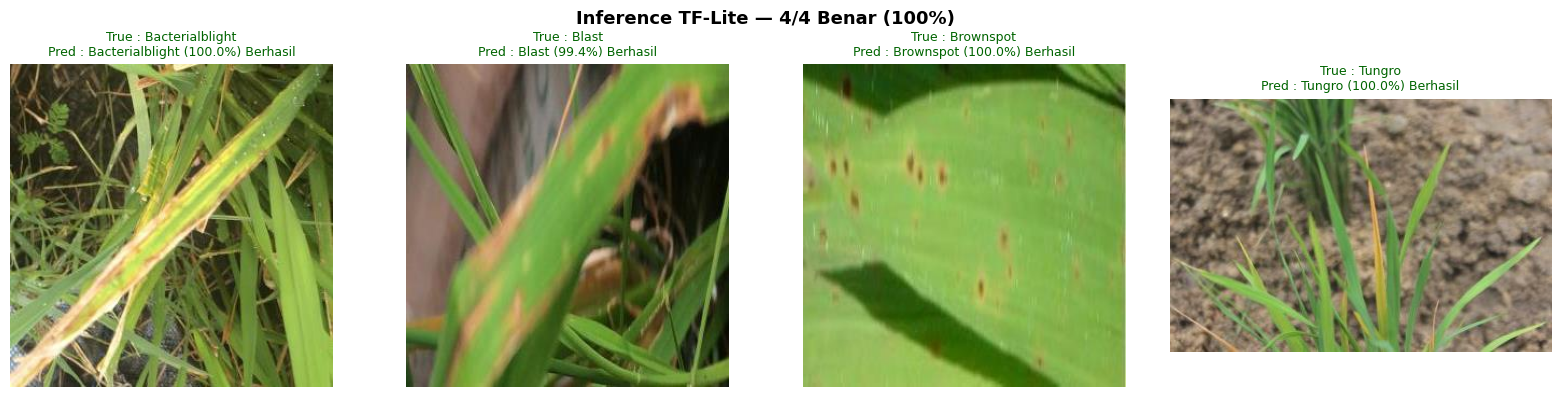


Disimpan: inference_result.png


In [22]:
# Ambil 1 sampel per kelas dari test set lalu prediksi
sample_pairs = []
for cls_dir in sorted(TEST_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    imgs = [f for f in cls_dir.iterdir()
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    if imgs:
        sample_pairs.append((cls_dir.name, random.choice(imgs)))

n    = len(sample_pairs)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

print('=' * 60)
print('HASIL INFERENCE — TF-LITE MODEL')
print('=' * 60)

correct = 0
for i, (true_lbl, img_path) in enumerate(sample_pairs):
    pred_lbl, conf, probs = predict_tflite(img_path)
    ok      = pred_lbl == true_lbl
    correct += int(ok)
    status  = 'Berhasil' if ok else 'Gagal'

    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(
        f'True : {true_lbl}\nPred : {pred_lbl} ({conf:.1f}%) {status}',
        fontsize=9,
        color='darkgreen' if ok else 'crimson'
    )
    axes[i].axis('off')

    print(f'\n[{i+1}] {img_path.name}')
    print(f'  True Label  : {true_lbl}')
    print(f'  Prediction  : {pred_lbl} ({conf:.1f}%) {status}')
    print('  Probabilities:')
    for lbl, p in sorted(zip(class_labels, probs), key=lambda x: -x[1]):
        bar = chr(9608) * int(p * 25)
        print(f'    {lbl:<8} {p*100:5.1f}%  {bar}')

# Sembunyikan axes kosong
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    f'Inference TF-Lite — {correct}/{n} Benar ({correct/n*100:.0f}%)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('inference_result.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDisimpan: inference_result.png')

In [23]:
# Buat requirements.txt menggunakan pip freeze
!pip freeze > requirements.txt
print('requirements.txt berhasil dibuat.')
print('\nLibrary utama yang tercantum:')
!grep -iE 'tensorflow|numpy|matplotlib|seaborn|scikit|Pillow' requirements.txt

requirements.txt berhasil dibuat.

Library utama yang tercantum:
matplotlib==3.10.0
matplotlib-inline==0.2.1
matplotlib-venn==1.1.2
numpy==2.0.2
pillow==11.3.0
scikit-image==0.25.2
scikit-learn==1.6.1
seaborn==0.13.2
tensorflow==2.19.0
tensorflow-datasets==4.9.9
tensorflow-hub==0.16.1
tensorflow-metadata==1.17.3
tensorflow-probability==0.25.0
tensorflow-text==2.19.0
tensorflow_decision_forests==1.12.0
tensorflowjs==4.22.0
